In [ ]:
!pip install ultralytics

In [1]:
from ultralytics import YOLO

yolov5n = YOLO("yolov5n.pt")
yolov5s = YOLO("yolov5s.pt")
yolov5m = YOLO("yolov5m.pt")
yolov5l = YOLO("yolov5l.pt")
yolov5x = YOLO("yolov5x.pt")

PRO TIP  Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

PRO TIP  Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

PRO TIP  Replace 'model=yolov5m.pt' with new 'model=yolov5mu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

PRO TIP  Replace 'model=yolov5l.pt' with new 'model=yolov5lu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.c

In [2]:
yolov5n.export(format ="onnx")
yolov5s.export(format ="onnx")
yolov5m.export(format ="onnx")
yolov5l.export(format ="onnx")
yolov5x.export(format ="onnx")

Ultralytics 8.3.204  Python-3.11.13 torch-2.8.0+cpu CPU (Intel Core i5-8250U 1.60GHz)
YOLOv5n summary (fused): 84 layers, 2,649,200 parameters, 0 gradients, 7.7 GFLOPs

PyTorch: starting from 'yolov5nu.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.3 MB)

ONNX: starting export with onnx 1.19.0 opset 22...
ONNX: slimming with onnxslim 0.1.70...
ONNX: export success  4.3s, saved as 'yolov5nu.onnx' (10.3 MB)

Export complete (4.9s)
Results saved to G:\OpenCV\module15-object-detection-YOLOv5\module15-object-detection\MyPractice
Predict:         yolo predict task=detect model=yolov5nu.onnx imgsz=640  
Validate:        yolo val task=detect model=yolov5nu.onnx imgsz=640 data=coco.yaml  
Visualize:       https://netron.app
Ultralytics 8.3.204  Python-3.11.13 torch-2.8.0+cpu CPU (Intel Core i5-8250U 1.60GHz)
YOLOv5s summary (fused): 84 layers, 9,142,496 parameters, 0 gradients, 24.0 GFLOPs

PyTorch: starting from 'yolov5su.pt' with input shape (1, 3, 640, 640) B

'yolov5xu.onnx'

In [3]:
import os
import numpy as np
import cv2
import sys
import time
import requests
import zipfile
from os import path
import matplotlib.pyplot as plt

C:\Users\dell\miniconda3\envs\opencv-env\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [4]:
from ultralytics.utils import YAML
from ultralytics.utils.checks import check_yaml

In [5]:
plt.rcParams['figure.figsize'] = (10,10)
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 14

In [24]:
INPUT_WIDTH = 640
INPUT_HEIGHT = 640
CONFIDENCE_THRESHOLD = 0.5
NMS_THRESHOLD = 0.4

In [25]:
FONT_FACE = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 2.5
THICKNESS = 4

In [26]:
#colors
BLACK = (0,0,0)
YELLOW = (0,255,255)
BLUE = (255,178,50)
RED = (0,0,255)
WHITE = (255,255,255)

In [35]:
CLASSES = YAML.load(check_yaml("coco8.yaml"))["names"]

for class_ in CLASSES.values():
    print(class_)

person
bicycle
car
motorcycle
airplane
bus
train
truck
boat
traffic light
fire hydrant
stop sign
parking meter
bench
bird
cat
dog
horse
sheep
cow
elephant
bear
zebra
giraffe
backpack
umbrella
handbag
tie
suitcase
frisbee
skis
snowboard
sports ball
kite
baseball bat
baseball glove
skateboard
surfboard
tennis racket
bottle
wine glass
cup
fork
knife
spoon
bowl
banana
apple
sandwich
orange
broccoli
carrot
hot dog
pizza
donut
cake
chair
couch
potted plant
bed
dining table
toilet
tv
laptop
mouse
remote
keyboard
cell phone
microwave
oven
toaster
sink
refrigerator
book
clock
vase
scissors
teddy bear
hair drier
toothbrush


In [10]:
COLORS = np.random.uniform(0,255,size=(len(CLASSES),3))

In [11]:
COLORS

array([[     84.234,      75.934,       214.6],
       [     183.17,      210.76,      100.69],
       [     212.64,      73.104,      239.97],
       [      244.9,      119.68,       203.1],
       [     177.22,      97.716,      191.71],
       [     246.06,      204.54,      6.1683],
       [     214.16,      178.83,      149.27],
       [     58.443,       52.87,      231.86],
       [     91.166,      207.95,      219.07],
       [     145.76,      71.378,      33.886],
       [     242.68,      45.622,      200.37],
       [     7.5723,      215.54,      208.74],
       [      101.7,      159.44,      127.59],
       [     187.34,      170.04,       252.4],
       [     174.43,      18.228,       98.99],
       [     43.537,      29.062,      125.78],
       [      70.38,        41.8,      121.95],
       [     130.45,       222.5,      120.39],
       [     98.082,      200.63,      226.42],
       [     29.834,      147.71,         168],
       [     182.22,      32.891,      1

In [27]:
def inference(input_image, net):
    blob = cv2.dnn.blobFromImage(input_image, 1/255, (INPUT_WIDTH,INPUT_HEIGHT),[0,0,0], 1, crop = False)

    net.setInput(blob)
    output_layers = net.getUnconnectedOutLayersNames()
    image_data = net.forward(output_layers)
    return image_data

In [28]:
def post_process(input_image,output):
    
    outputs = np.transpose(np.squeeze(output[0]))

    rows = outputs.shape[0]

    boxes = []
    scores = []
    class_ids = []
    img_height, img_width = input_image.shape[:2]

    x_factor = img_width / INPUT_WIDTH
    y_factor = img_height / INPUT_HEIGHT

    for i in range(rows):

        classes_scores = outputs[i][4:]
        max_score = np.amax(classes_scores)

        if max_score > CONFIDENCE_THRESHOLD:
            class_id = np.argmax(classes_scores)

            x, y, w, h = outputs[i][0], outputs[i][1], outputs[i][2], outputs[i][3]

            left = int((x - w/2) * x_factor)
            top = int((y - h/2) * y_factor)
            width = int( w * x_factor)
            height = int( h * y_factor)

            class_ids.append(class_id)
            scores.append(max_score)
            boxes.append([left, top, width, height])

    indices = cv2.dnn.NMSBoxes(boxes, scores, CONFIDENCE_THRESHOLD, NMS_THRESHOLD)

    for i in indices:
        box = boxes[i]
        score = scores[i]
        class_id = class_ids[i]

        draw_detections(input_image, box, score,class_id)

    return input_image

In [20]:
def draw_detections(img, box, score, class_id):
    x1, y1, w, h = box

    color = COLORS[class_id]

    cv2.rectangle(img, (int(x1),int(y1)),(int(x1 + w),int(y1 + h)), color, 2)

    label = f"{CLASSES[class_id]} : {score:.2f}"

    (label_width, label_height), _ = cv2.getTextSize(label,FONT_FACE, FONT_SCALE, THICKNESS)

    label_x = x1
    label_y = y1 - 10 if y1 - 10 > label_height else y1 + 10

    cv2.rectangle(
        img, (label_x, label_y - label_height), (label_x + label_width, label_y + label_height), color, cv2.FILLED
    )

    cv2.putText(img, label, (label_x,label_y), FONT_FACE, FONT_SCALE, (0,0,0), THICKNESS, cv2.LINE_AA)

In [29]:
def put_efficiency(input_img, inference_time, is_video=False):
    if is_video:
        fps = 1 / inference_time
        label = 'FPS: %.2f' % fps

    else:
        label = 'Inference Time: %.2f ms' % (inference_time * 1000.0)

    cv2.putText(input_img, label, (30,80), FONT_FACE, FONT_SCALE, (0,255,0), THICKNESS, cv2.LINE_AA)

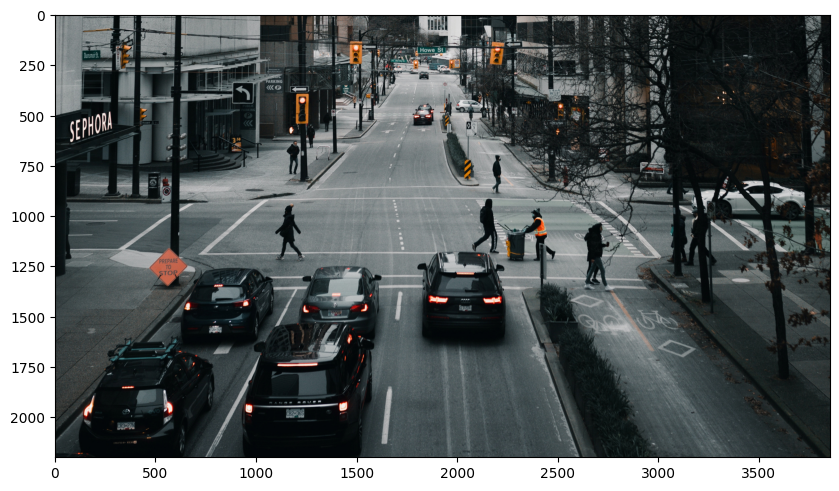

In [30]:
frame = cv2.imread('../street.jpg')
classFile = "../coco.names"
classes = None

with open(classFile, 'rt') as f:
    classes = f.read().rstrip('\n').split('\n')

plt.imshow(frame[...,::-1])

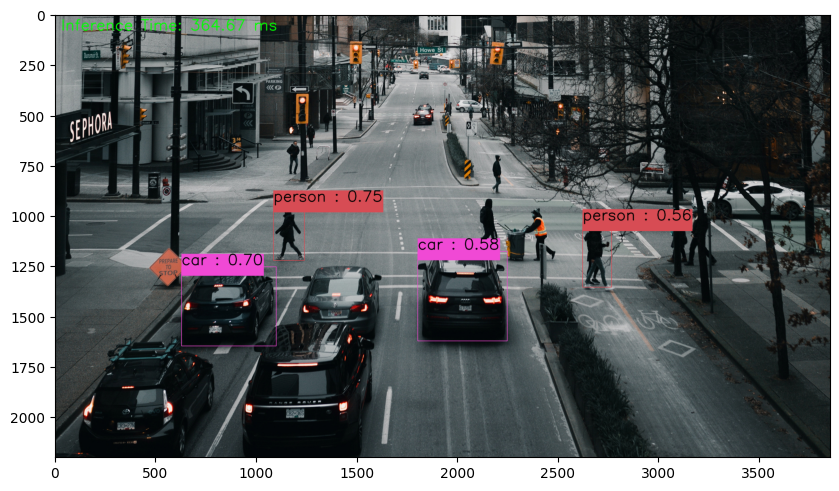

In [32]:
model = 'yolov5nu.onnx'
net = cv2.dnn.readNetFromONNX(model)

start_time = time.time()

detections = inference(frame, net)

inference_time = time.time() - start_time

img = post_process(frame.copy(), detections)

put_efficiency(img, inference_time, is_video=False)

cv2.imwrite("result.jpg", img)

plt.imshow(img[:,:,::-1])
plt.show()

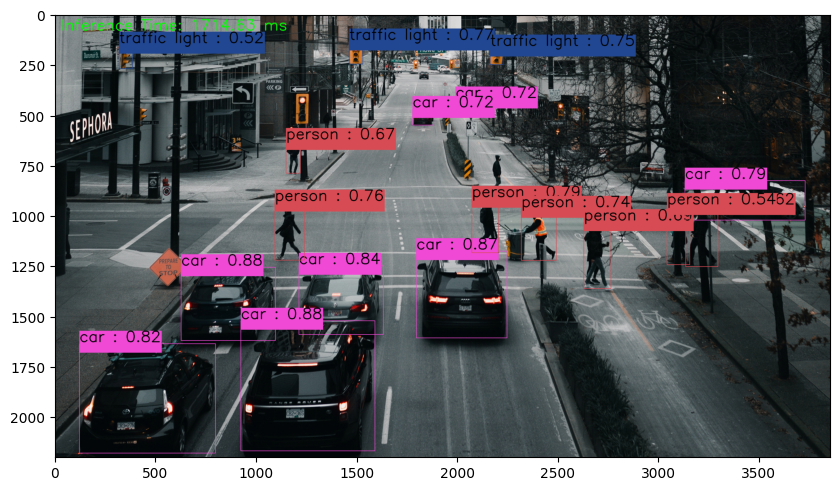

In [33]:
model = 'yolov5mu.onnx'
net = cv2.dnn.readNetFromONNX(model)

start_time = time.time()

detections = inference(frame, net)

inference_time = time.time() - start_time

img = post_process(frame.copy(), detections)

put_efficiency(img, inference_time, is_video=False)

cv2.imwrite("result.jpg", img)

plt.imshow(img[:,:,::-1])
plt.show()

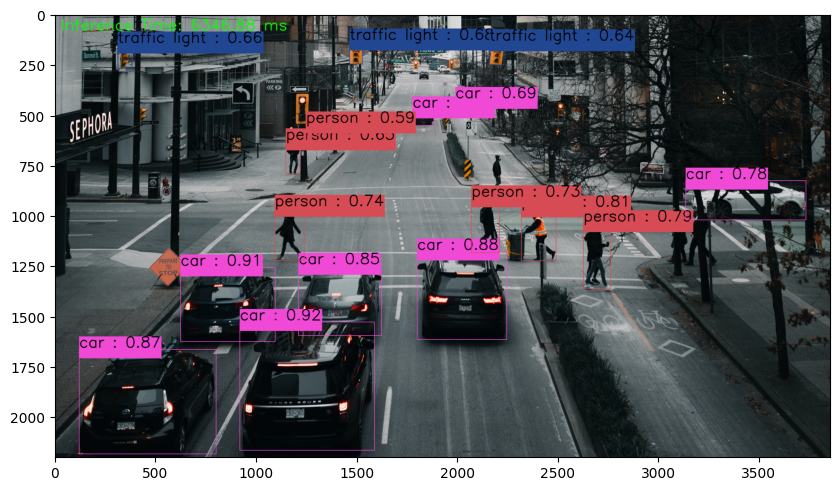

In [34]:
model = 'yolov5xu.onnx'
net = cv2.dnn.readNetFromONNX(model)

start_time = time.time()

detections = inference(frame, net)

inference_time = time.time() - start_time

img = post_process(frame.copy(), detections)

put_efficiency(img, inference_time, is_video=False)

cv2.imwrite("result.jpg", img)

plt.imshow(img[:,:,::-1])
plt.show()